# Ames Housing Price Prediction — Modeling

This notebook begins the modeling stage of the Ames Housing Price
Prediction project.

The objective is to build regression models that predict `SalePrice`
from the available house characteristics.

The modeling workflow will follow:

1. Load and prepare the data
2. Separate predictors and target
3. Create training and testing sets
4. Build a preprocessing pipeline
5. Train a baseline Linear Regression model
6. Generate predictions
7. Evaluate the model
8. Compare increasingly powerful models
9. Tune the final candidates

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error
)

In [2]:
data_path = "../artifacts/data_ingestion/AmesHousing.txt"

df = pd.read_csv(
    data_path,
    sep="\t"
)

print("Shape:", df.shape)

df.head()

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
X = df.drop(
    columns=["SalePrice"]
)

y = df["SalePrice"]

In [4]:
print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "SalePrice in X:",
    "SalePrice" in X.columns
)

X shape: (2930, 81)
y shape: (2930,)
SalePrice in X: False


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (2344, 81)
X_test: (586, 81)
y_train: (2344,)
y_test: (586,)


In [7]:
numerical_features = (
    X_train
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

In [8]:
print(
    "Numerical features:",
    len(numerical_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

Numerical features: 38
Categorical features: 43


In [9]:
categorical_missing = (
    X_train[categorical_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

categorical_missing[
    categorical_missing > 0
]

Pool QC           2332
Misc Feature      2250
Alley             2182
Fence             1874
Mas Vnr Type      1426
Fireplace Qu      1144
Garage Cond        122
Garage Qual        122
Garage Finish      122
Garage Type        120
Bsmt Exposure       63
BsmtFin Type 2      62
BsmtFin Type 1      61
Bsmt Qual           61
Bsmt Cond           61
dtype: int64

In [10]:
absence_categorical = [
    "Alley",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Pool QC",
    "Fence"
]

In [11]:
[
    column
    for column in absence_categorical
    if column in X_train.columns
]

['Alley',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin Type 2',
 'Fireplace Qu',
 'Garage Type',
 'Garage Finish',
 'Garage Qual',
 'Garage Cond',
 'Pool QC',
 'Fence']

In [12]:
categorical_none_features = [
    column
    for column in absence_categorical
    if column in categorical_features
]

categorical_other_features = [
    column
    for column in categorical_features
    if column not in categorical_none_features
]

In [13]:
print(
    "Categorical features using 'None':",
    len(categorical_none_features)
)

print(
    "Other categorical features:",
    len(categorical_other_features)
)

Categorical features using 'None': 13
Other categorical features: 30


In [14]:
categorical_none_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="None"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [15]:
categorical_other_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [16]:
numerical_missing = (
    X_train[numerical_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

numerical_missing[
    numerical_missing > 0
]

Lot Frontage      393
Garage Yr Blt     122
Mas Vnr Area       19
BsmtFin SF 2        1
Bsmt Unf SF         1
Total Bsmt SF       1
Garage Cars         1
Garage Area         1
Bsmt Full Bath      1
BsmtFin SF 1        1
Bsmt Half Bath      1
dtype: int64

In [17]:
numerical_zero_features = [
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "Garage Cars",
    "Garage Area"
]

In [18]:
[
    column
    for column in numerical_zero_features
    if column in numerical_features
]

['BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Garage Cars',
 'Garage Area']

In [19]:
numerical_zero_features = [
    column
    for column in numerical_zero_features
    if column in numerical_features
]

In [20]:
numerical_median_features = [
    column
    for column in numerical_features
    if column not in numerical_zero_features
]

In [21]:
print(
    "Numerical features using zero:",
    len(numerical_zero_features)
)

print(
    "Numerical features using median:",
    len(numerical_median_features)
)

Numerical features using zero: 8
Numerical features using median: 30


In [22]:
numerical_zero_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value=0
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [23]:
numerical_median_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num_zero",
            numerical_zero_pipeline,
            numerical_zero_features
        ),
        (
            "num_median",
            numerical_median_pipeline,
            numerical_median_features
        ),
        (
            "cat_none",
            categorical_none_pipeline,
            categorical_none_features
        ),
        (
            "cat_other",
            categorical_other_pipeline,
            categorical_other_features
        )
    ]
)

In [25]:
model_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

In [26]:
model_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](81,)","['Order','PID','MS SubClass',...,'Yr Sold','Sale Type','Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,81
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_zero', ...), ('num_median', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [27]:
y_pred = model_pipeline.predict(
    X_test
)

In [28]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:,.2f}")

MAE  : 15,844.16
RMSE : 29,280.71
R²   : 0.8931
RMSE : 29,280.71


In [29]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison["Error"] = (
    comparison["Actual"]
    - comparison["Predicted"]
)

comparison["AbsoluteError"] = (
    comparison["Error"]
    .abs()
)

comparison.head(10)

,Actual,Predicted,Error,AbsoluteError
1357,161000,156788.381006,4211.618994,4211.618994
2367,116000,109523.490425,6476.509575,6476.509575
2822,196500,199673.686769,-3173.686769,3173.686769
2126,123600,133334.373804,-9734.373804,9734.373804
1544,126000,132361.352715,-6361.352715,6361.352715
2415,174190,193149.938769,-18959.938769,18959.938769
2227,200000,169382.880522,30617.119478,30617.119478
410,148500,145527.284777,2972.715223,2972.715223
761,88750,98520.231703,-9770.231703,9770.231703
436,409900,364004.695002,45895.304998,45895.304998


In [30]:
comparison.sort_values(
    "AbsoluteError",
    ascending=False
).head(10)

,Actual,Predicted,Error,AbsoluteError
2181,184750,610269.681134,-425519.681134,425519.681134
433,582933,424590.682766,158342.317234,158342.317234
44,611657,457162.747546,154494.252454,154494.252454
2445,625000,487042.609017,137957.390983,137957.390983
432,610000,505733.827565,104266.172435,104266.172435
944,230000,333978.903626,-103978.903626,103978.903626
2043,50000,-34865.525424,84865.525424,84865.525424
1538,311500,226711.943308,84788.056692,84788.056692
456,552000,469968.415205,82031.584795,82031.584795
1559,392500,313924.942795,78575.057205,78575.057205


In [31]:
from sklearn.linear_model import Ridge

In [32]:
ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

In [33]:
ridge_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](81,)","['Order','PID','MS SubClass',...,'Yr Sold','Sale Type','Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,81
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_zero', ...), ('num_median', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [34]:
ridge_pred = ridge_pipeline.predict(
    X_test
)

In [35]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print(
    f"Ridge MAE  : {ridge_mae:,.2f}"
)

print(
    f"Ridge RMSE : {ridge_rmse:,.2f}"
)

print(
    f"Ridge R²   : {ridge_r2:.4f}"
)

Ridge MAE  : 16,254.55
Ridge RMSE : 28,887.24
Ridge R²   : 0.8959


In [36]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge"
    ],
    "MAE": [
        mae,
        ridge_mae
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R2": [
        r2,
        ridge_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,15844.157881,29280.706590,0.893065
1,Ridge,16254.554981,28887.241093,0.895919


In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
alpha_values = [
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

In [39]:
param_grid = {
    "model__alpha": alpha_values
}

In [40]:
ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [41]:
ridge_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information

In [42]:
print(
    "Best alpha:",
    ridge_grid.best_params_
)

Best alpha: {'model__alpha': 10}


In [43]:
print(
    "Best CV score:",
    ridge_grid.best_score_
)

Best CV score: -27748.08005651948


In [44]:
cv_results = pd.DataFrame(
    ridge_grid.cv_results_
)

cv_results[
    [
        "param_model__alpha",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
)

,param_model__alpha,mean_test_score,std_test_score,rank_test_score
3,10.00,-27748.080057,4892.732327,1
2,1.00,-28133.958411,5702.521630,2
4,100.00,-28590.151748,4727.842393,3
1,0.10,-29598.157353,6986.297838,4
0,0.01,-30355.002549,7372.983604,5
5,1000.00,-31601.508983,3538.723347,6


In [45]:
cv_summary = cv_results[
    [
        "param_model__alpha",
        "mean_test_score",
        "std_test_score"
    ]
].copy()

cv_summary["mean_cv_rmse"] = (
    -cv_summary["mean_test_score"]
)

cv_summary["std_cv_rmse"] = (
    cv_summary["std_test_score"]
)

cv_summary = cv_summary[
    [
        "param_model__alpha",
        "mean_cv_rmse",
        "std_cv_rmse"
    ]
].sort_values(
    "mean_cv_rmse"
)

cv_summary

,param_model__alpha,mean_cv_rmse,std_cv_rmse
3,10.00,27748.080057,4892.732327
2,1.00,28133.958411,5702.521630
4,100.00,28590.151748,4727.842393
1,0.10,29598.157353,6986.297838
0,0.01,30355.002549,7372.983604
5,1000.00,31601.508983,3538.723347


In [46]:
best_ridge = ridge_grid.best_estimator_

In [47]:
tuned_ridge_pred = (
    best_ridge.predict(X_test)
)

In [48]:
tuned_ridge_mae = (
    mean_absolute_error(
        y_test,
        tuned_ridge_pred
    )
)

tuned_ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_ridge_pred
    )
)

tuned_ridge_r2 = (
    r2_score(
        y_test,
        tuned_ridge_pred
    )
)

In [49]:
print(
    f"Tuned Ridge MAE  : {tuned_ridge_mae:,.2f}"
)

print(
    f"Tuned Ridge RMSE : {tuned_ridge_rmse:,.2f}"
)

print(
    f"Tuned Ridge R²   : {tuned_ridge_r2:.4f}"
)

Tuned Ridge MAE  : 16,624.55
Tuned Ridge RMSE : 29,167.34
Tuned Ridge R²   : 0.8939


In [50]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (alpha=1)",
        "Tuned Ridge"
    ],
    "MAE": [
        mae,
        ridge_mae,
        tuned_ridge_mae
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        tuned_ridge_rmse
    ],
    "R2": [
        r2,
        ridge_r2,
        tuned_ridge_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,15844.157881,29280.706590,0.893065
1,Ridge (alpha=1),16254.554981,28887.241093,0.895919
2,Tuned Ridge,16624.552009,29167.338188,0.893891


In [51]:
from sklearn.linear_model import Lasso

In [52]:
lasso_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Lasso(
                alpha=0.001,
                max_iter=10000
            )
        )
    ]
)

In [53]:
lasso_pipeline.fit(
    X_train,
    y_train
)

e:\Project_Works\ML_Learn\Ames Housing Prices\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.032594e+11, tolerance: 1.394e+09
  model = cd_fast.sparse_enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](81,)","['Order','PID','MS SubClass',...,'Yr Sold','Sale Type','Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,81
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_zero', ...), ('num_median', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [54]:
lasso_pred = lasso_pipeline.predict(
    X_test
)

In [55]:
lasso_mae = mean_absolute_error(
    y_test,
    lasso_pred
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lasso_pred
    )
)

lasso_r2 = r2_score(
    y_test,
    lasso_pred
)

print(
    f"Lasso MAE  : {lasso_mae:,.2f}"
)

print(
    f"Lasso RMSE : {lasso_rmse:,.2f}"
)

print(
    f"Lasso R²   : {lasso_r2:.4f}"
)

Lasso MAE  : 15,841.10
Lasso RMSE : 29,259.78
Lasso R²   : 0.8932


In [56]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (alpha=1)",
        "Tuned Ridge",
        "Lasso (alpha=0.001)"
    ],
    "MAE": [
        mae,
        ridge_mae,
        tuned_ridge_mae,
        lasso_mae
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        tuned_ridge_rmse,
        lasso_rmse
    ],
    "R2": [
        r2,
        ridge_r2,
        tuned_ridge_r2,
        lasso_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,15844.157881,29280.706590,0.893065
1,Ridge (alpha=1),16254.554981,28887.241093,0.895919
2,Tuned Ridge,16624.552009,29167.338188,0.893891
3,Lasso (alpha=0.001),15841.095102,29259.781920,0.893217


In [57]:
lasso_model = (
    lasso_pipeline
    .named_steps["model"]
)

In [58]:
feature_names = (
    lasso_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [59]:
print(
    "Number of transformed features:",
    len(feature_names)
)

Number of transformed features: 315


In [60]:
lasso_coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lasso_model.coef_
})

In [61]:
zero_coefficients = (
    lasso_coefficients["coefficient"] == 0
).sum()

total_coefficients = len(
    lasso_coefficients
)

print(
    "Zero coefficients:",
    zero_coefficients
)

print(
    "Total coefficients:",
    total_coefficients
)

print(
    "Percentage zero:",
    f"{zero_coefficients / total_coefficients * 100:.2f}%"
)

Zero coefficients: 6
Total coefficients: 315
Percentage zero: 1.90%


In [62]:
lasso_zero_features = (
    lasso_coefficients[
        lasso_coefficients["coefficient"] == 0
    ]
    .sort_values("feature")
)

lasso_zero_features

,feature,coefficient
50,cat_none__Bsmt Cond_None,0.0
52,cat_none__Bsmt Cond_TA,-0.0
98,cat_none__Garage Cond_None,0.0
274,cat_other__Central Air_Y,-0.0
237,cat_other__Exterior 2nd_PreCast,0.0
294,cat_other__Paved Drive_Y,0.0


In [63]:
lasso_coefficients.sort_values(
    "coefficient",
    ascending=False
).head(15)

,feature,coefficient
149,cat_other__Neighborhood_GrnHill,104846.531900
101,cat_none__Pool QC_Ex,87873.054595
89,cat_none__Garage Qual_Ex,79974.334645
221,cat_other__Exterior 1st_PreCast,57197.317030
205,cat_other__Roof Matl_Membran,53145.731704
114,cat_other__MS Zoning_I (all),50080.856038
51,cat_none__Bsmt Cond_Po,43181.151686
164,cat_other__Neighborhood_StoneBr,41802.303713
210,cat_other__Roof Matl_WdShngl,41588.814092
44,cat_none__Bsmt Qual_None,38968.558915


In [64]:
lasso_coefficients.sort_values(
    "coefficient",
    ascending=True
).head(15)

,feature,coefficient
203,cat_other__Roof Matl_ClyTile,-700685.689235
295,cat_other__Misc Feature_Elev,-541196.768279
289,cat_other__Functional_Sal,-89734.348898
245,cat_other__Mas Vnr Type_CBlock,-84561.009484
95,cat_none__Garage Cond_Ex,-61240.604288
290,cat_other__Functional_Sev,-41084.788614
181,cat_other__Condition 2_RRAe,-34280.775852
138,cat_other__Land Slope_Sev,-32186.347522
238,cat_other__Exterior 2nd_Stone,-29176.837221
278,cat_other__Electrical_Mix,-27754.090675


In [65]:
lasso_alpha_values = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1
]

In [66]:
lasso_param_grid = {
    "model__alpha": lasso_alpha_values
}

In [67]:
lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [68]:
lasso_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informati

In [69]:
print(
    "Best Lasso alpha:",
    lasso_grid.best_params_
)

Best Lasso alpha: {'model__alpha': 1}


In [70]:
print(
    "Best CV RMSE:",
    -lasso_grid.best_score_
)

Best CV RMSE: 29862.915996443488


In [71]:
best_lasso = (
    lasso_grid.best_estimator_
)

tuned_lasso_pred = (
    best_lasso.predict(X_test)
)

In [72]:
tuned_lasso_mae = (
    mean_absolute_error(
        y_test,
        tuned_lasso_pred
    )
)

tuned_lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_lasso_pred
    )
)

tuned_lasso_r2 = (
    r2_score(
        y_test,
        tuned_lasso_pred
    )
)

In [73]:
print(
    f"Tuned Lasso MAE  : {tuned_lasso_mae:,.2f}"
)

print(
    f"Tuned Lasso RMSE : {tuned_lasso_rmse:,.2f}"
)

print(
    f"Tuned Lasso R²   : {tuned_lasso_r2:.4f}"
)

Tuned Lasso MAE  : 15,767.31
Tuned Lasso RMSE : 29,122.72
Tuned Lasso R²   : 0.8942


In [74]:
from sklearn.tree import DecisionTreeRegressor

In [75]:
tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

In [76]:
tree_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](81,)","['Order','PID','MS SubClass',...,'Yr Sold','Sale Type','Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,81
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_zero', ...), ('num_median', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [77]:
tree_pred = tree_pipeline.predict(
    X_test
)

In [78]:
tree_mae = mean_absolute_error(
    y_test,
    tree_pred
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_pred
    )
)

tree_r2 = r2_score(
    y_test,
    tree_pred
)

print(
    f"Tree MAE  : {tree_mae:,.2f}"
)

print(
    f"Tree RMSE : {tree_rmse:,.2f}"
)

print(
    f"Tree R²   : {tree_r2:.4f}"
)

Tree MAE  : 24,104.51
Tree RMSE : 36,158.37
Tree R²   : 0.8369


In [79]:
tree_train_pred = (
    tree_pipeline.predict(
        X_train
    )
)

In [80]:
tree_train_r2 = r2_score(
    y_train,
    tree_train_pred
)

print(
    f"Training R²: {tree_train_r2:.4f}"
)

print(
    f"Test R²:     {tree_r2:.4f}"
)

Training R²: 1.0000
Test R²:     0.8369


In [81]:
tree_depth_5 = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

In [82]:
tree_depth_5.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](81,)","['Order','PID','MS SubClass',...,'Yr Sold','Sale Type','Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,81
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_zero', ...), ('num_median', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [83]:
tree_depth_5_pred = (
    tree_depth_5.predict(
        X_test
    )
)

In [84]:
tree_depth_5_mae = (
    mean_absolute_error(
        y_test,
        tree_depth_5_pred
    )
)

tree_depth_5_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_depth_5_pred
    )
)

tree_depth_5_r2 = (
    r2_score(
        y_test,
        tree_depth_5_pred
    )
)

print(
    f"Depth 5 MAE  : {tree_depth_5_mae:,.2f}"
)

print(
    f"Depth 5 RMSE : {tree_depth_5_rmse:,.2f}"
)

print(
    f"Depth 5 R²   : {tree_depth_5_r2:.4f}"
)

Depth 5 MAE  : 24,712.18
Depth 5 RMSE : 35,808.78
Depth 5 R²   : 0.8401


In [85]:
tree_depth_5_train_pred = (
    tree_depth_5.predict(
        X_train
    )
)

tree_depth_5_train_r2 = (
    r2_score(
        y_train,
        tree_depth_5_train_pred
    )
)

print(
    f"Training R²: "
    f"{tree_depth_5_train_r2:.4f}"
)

print(
    f"Test R²:     "
    f"{tree_depth_5_r2:.4f}"
)

Training R²: 0.8492
Test R²:     0.8401


In [86]:
tree_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree (unrestricted)",
        "Decision Tree (depth=5)"
    ],
    "MAE": [
        tree_mae,
        tree_depth_5_mae
    ],
    "RMSE": [
        tree_rmse,
        tree_depth_5_rmse
    ],
    "R2": [
        tree_r2,
        tree_depth_5_r2
    ]
})

tree_comparison

,Model,MAE,RMSE,R2
0,Decision Tree (unrestricted),24104.513652,36158.367020,0.836929
1,Decision Tree (depth=5),24712.180072,35808.779355,0.840067


In [87]:
tree_model = (
    tree_pipeline
    .named_steps["model"]
)

In [88]:
print(
    "Number of leaves:",
    tree_model.get_n_leaves()
)

print(
    "Tree depth:",
    tree_model.get_depth()
)

Number of leaves: 2230
Tree depth: 24


In [89]:
tree_depth_5_model = (
    tree_depth_5
    .named_steps["model"]
)

print(
    "Depth-5 leaves:",
    tree_depth_5_model.get_n_leaves()
)

print(
    "Depth-5 actual depth:",
    tree_depth_5_model.get_depth()
)

Depth-5 leaves: 32
Depth-5 actual depth: 5


In [90]:
tree_param_grid = {
    "model__max_depth": [
        3,
        5,
        7,
        10,
        15,
        None
    ],
    "model__min_samples_leaf": [
        1,
        2,
        5,
        10
    ]
}

In [91]:
tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [92]:
tree_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [93]:
print(
    "Best parameters:"
)

print(
    tree_grid.best_params_
)

print(
    "Best CV RMSE:",
    -tree_grid.best_score_
)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 10}
Best CV RMSE: 34049.92396084495


In [94]:
best_tree = (
    tree_grid.best_estimator_
)

In [95]:
tuned_tree_pred = (
    best_tree.predict(X_test)
)

In [96]:
tuned_tree_mae = (
    mean_absolute_error(
        y_test,
        tuned_tree_pred
    )
)

tuned_tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_tree_pred
    )
)

tuned_tree_r2 = (
    r2_score(
        y_test,
        tuned_tree_pred
    )
)

print(
    f"Tuned Tree MAE  : "
    f"{tuned_tree_mae:,.2f}"
)

print(
    f"Tuned Tree RMSE : "
    f"{tuned_tree_rmse:,.2f}"
)

print(
    f"Tuned Tree R²   : "
    f"{tuned_tree_r2:.4f}"
)

Tuned Tree MAE  : 22,455.25
Tuned Tree RMSE : 36,926.36
Tuned Tree R²   : 0.8299


In [97]:
from sklearn.ensemble import RandomForestRegressor

In [98]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [99]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](81,)","['Order','PID','MS SubClass',...,'Yr Sold','Sale Type','Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,81
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_zero', ...), ('num_median', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [101]:
rf_pred = (
    random_forest_pipeline
    .predict(X_test)
)

In [102]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

In [103]:
print(
    f"Random Forest MAE  : "
    f"{rf_mae:,.2f}"
)

print(
    f"Random Forest RMSE : "
    f"{rf_rmse:,.2f}"
)

print(
    f"Random Forest R²   : "
    f"{rf_r2:.4f}"
)

Random Forest MAE  : 15,887.29
Random Forest RMSE : 26,907.42
Random Forest R²   : 0.9097


In [104]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (alpha=1)",
        "Tuned Ridge",
        "Lasso (initial)",
        "Tuned Lasso",
        "Decision Tree",
        "Decision Tree (depth=5)",
        "Tuned Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        ridge_mae,
        tuned_ridge_mae,
        lasso_mae,
        tuned_lasso_mae,
        tree_mae,
        tree_depth_5_mae,
        tuned_tree_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        tuned_ridge_rmse,
        lasso_rmse,
        tuned_lasso_rmse,
        tree_rmse,
        tree_depth_5_rmse,
        tuned_tree_rmse,
        rf_rmse
    ],
    "R2": [
        r2,
        ridge_r2,
        tuned_ridge_r2,
        lasso_r2,
        tuned_lasso_r2,
        tree_r2,
        tree_depth_5_r2,
        tuned_tree_r2,
        rf_r2
    ]
})

model_comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,R2
8,Random Forest,15887.290981,26907.415567,0.909697
1,Ridge (alpha=1),16254.554981,28887.241093,0.895919
4,Tuned Lasso,15767.309855,29122.722570,0.894215
2,Tuned Ridge,16624.552009,29167.338188,0.893891
3,Lasso (initial),15841.095102,29259.781920,0.893217
0,Linear Regression,15844.157881,29280.706590,0.893065
6,Decision Tree (depth=5),24712.180072,35808.779355,0.840067
5,Decision Tree,24104.513652,36158.367020,0.836929
7,Tuned Decision Tree,22455.248755,36926.357376,0.829929


In [105]:
rf_train_pred = (
    random_forest_pipeline
    .predict(X_train)
)

In [106]:
rf_train_r2 = r2_score(
    y_train,
    rf_train_pred
)

print(
    f"Random Forest Training R²: "
    f"{rf_train_r2:.4f}"
)

print(
    f"Random Forest Test R²:     "
    f"{rf_r2:.4f}"
)

Random Forest Training R²: 0.9837
Random Forest Test R²:     0.9097


In [107]:
rf_model = (
    random_forest_pipeline
    .named_steps["model"]
)

In [108]:
rf_feature_names = (
    random_forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [109]:
rf_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_model.feature_importances_
})

In [110]:
rf_importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
13,num_median__Overall Qual,0.602673
21,num_median__Gr Liv Area,0.100714
18,num_median__1st Flr SF,0.036766
3,num_zero__Total Bsmt SF,0.026663
0,num_zero__BsmtFin SF 1,0.022991
19,num_median__2nd Flr SF,0.022639
22,num_median__Full Bath,0.016712
6,num_zero__Garage Cars,0.016045
7,num_zero__Garage Area,0.014898
12,num_median__Lot Area,0.014419


In [111]:
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", 0.7]
}


In [112]:
rf_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [113]:
rf_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 0.7], 'model__min_samples_leaf': [1, 2, ...], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchang

In [114]:
print("Best parameters:")
print(rf_grid.best_params_)

Best parameters:
{'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}


In [115]:
print("Best parameters:")
print(rf_grid.best_params_)

Best parameters:
{'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}


In [116]:
best_rf = rf_grid.best_estimator_

In [117]:
rf_tuned_pred = best_rf.predict(
    X_test
)

In [118]:
rf_tuned_mae = mean_absolute_error(
    y_test,
    rf_tuned_pred
)

rf_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_tuned_pred
    )
)

rf_tuned_r2 = r2_score(
    y_test,
    rf_tuned_pred
)

In [119]:
print(
    f"Tuned Random Forest MAE  : "
    f"{rf_tuned_mae:,.2f}"
)

print(
    f"Tuned Random Forest RMSE : "
    f"{rf_tuned_rmse:,.2f}"
)

print(
    f"Tuned Random Forest R²   : "
    f"{rf_tuned_r2:.4f}"
)

Tuned Random Forest MAE  : 15,704.04
Tuned Random Forest RMSE : 26,818.21
Tuned Random Forest R²   : 0.9103


In [120]:
rf_tuned_train_pred = (
    best_rf.predict(X_train)
)

rf_tuned_train_r2 = r2_score(
    y_train,
    rf_tuned_train_pred
)

print(
    f"Tuned Random Forest "
    f"Training R²: "
    f"{rf_tuned_train_r2:.4f}"
)

print(
    f"Tuned Random Forest "
    f"Test R²: "
    f"{rf_tuned_r2:.4f}"
)

Tuned Random Forest Training R²: 0.9835
Tuned Random Forest Test R²: 0.9103


In [121]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (alpha=1)",
        "Tuned Ridge",
        "Decision Tree",
        "Decision Tree (depth=5)",
        "Tuned Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae,
        ridge_mae,
        tuned_ridge_mae,
        tree_mae,
        tree_depth_5_mae,
        tuned_tree_mae,
        rf_mae,
        rf_tuned_mae
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        tuned_ridge_rmse,
        tree_rmse,
        tree_depth_5_rmse,
        tuned_tree_rmse,
        rf_rmse,
        rf_tuned_rmse
    ],
    "R2": [
        r2,
        ridge_r2,
        tuned_ridge_r2,
        tree_r2,
        tree_depth_5_r2,
        tuned_tree_r2,
        rf_r2,
        rf_tuned_r2
    ]
})

In [122]:
model_comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,R2
7,Tuned Random Forest,15704.036348,26818.212080,0.910295
6,Random Forest,15887.290981,26907.415567,0.909697
1,Ridge (alpha=1),16254.554981,28887.241093,0.895919
2,Tuned Ridge,16624.552009,29167.338188,0.893891
0,Linear Regression,15844.157881,29280.706590,0.893065
4,Decision Tree (depth=5),24712.180072,35808.779355,0.840067
3,Decision Tree,24104.513652,36158.367020,0.836929
5,Tuned Decision Tree,22455.248755,36926.357376,0.829929


In [123]:
from sklearn.ensemble import GradientBoostingRegressor

In [124]:
gradient_boosting_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [125]:
gradient_boosting_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](81,)","['Order','PID','MS SubClass',...,'Yr Sold','Sale Type','Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,81
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_zero', ...), ('num_median', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [126]:
gb_pred = (
    gradient_boosting_pipeline
    .predict(X_test)
)

In [127]:
gb_mae = mean_absolute_error(
    y_test,
    gb_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_pred
    )
)

gb_r2 = r2_score(
    y_test,
    gb_pred
)

In [128]:
print(
    f"Gradient Boosting MAE  : "
    f"{gb_mae:,.2f}"
)

print(
    f"Gradient Boosting RMSE : "
    f"{gb_rmse:,.2f}"
)

print(
    f"Gradient Boosting R²   : "
    f"{gb_r2:.4f}"
)

Gradient Boosting MAE  : 15,124.10
Gradient Boosting RMSE : 25,485.15
Gradient Boosting R²   : 0.9190


In [129]:
gb_train_pred = (
    gradient_boosting_pipeline
    .predict(X_train)
)

gb_train_r2 = r2_score(
    y_train,
    gb_train_pred
)

print(
    f"Training R²: "
    f"{gb_train_r2:.4f}"
)

print(
    f"Test R²:     "
    f"{gb_r2:.4f}"
)

Training R²: 0.9621
Test R²:     0.9190


In [130]:
gb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

In [131]:
gb_grid = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [132]:
gb_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable add

In [133]:
print("Best parameters:")
print(gb_grid.best_params_)

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 300}


In [134]:
print(
    "Best CV RMSE:",
    -gb_grid.best_score_
)

Best CV RMSE: 22269.471888940134


In [135]:
best_gb = gb_grid.best_estimator_

In [136]:
gb_tuned_pred = best_gb.predict(
    X_test
)

In [137]:
gb_tuned_mae = mean_absolute_error(
    y_test,
    gb_tuned_pred
)

gb_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_tuned_pred
    )
)

gb_tuned_r2 = r2_score(
    y_test,
    gb_tuned_pred
)

In [138]:
print(
    f"Tuned Gradient Boosting MAE  : "
    f"{gb_tuned_mae:,.2f}"
)

print(
    f"Tuned Gradient Boosting RMSE : "
    f"{gb_tuned_rmse:,.2f}"
)

print(
    f"Tuned Gradient Boosting R²   : "
    f"{gb_tuned_r2:.4f}"
)

Tuned Gradient Boosting MAE  : 14,442.84
Tuned Gradient Boosting RMSE : 24,741.14
Tuned Gradient Boosting R²   : 0.9237


In [139]:
gb_tuned_train_pred = (
    best_gb.predict(X_train)
)

gb_tuned_train_r2 = r2_score(
    y_train,
    gb_tuned_train_pred
)

print(
    f"Training R²: "
    f"{gb_tuned_train_r2:.4f}"
)

print(
    f"Test R²:     "
    f"{gb_tuned_r2:.4f}"
)

Training R²: 0.9633
Test R²:     0.9237


In [143]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (alpha=1)",
        "Tuned Ridge",
        "Decision Tree",
        "Decision Tree (depth=5)",
        "Tuned Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "GB",
        "Tuned Gradient Boosting"
    ],
    "MAE": [
        mae,
        ridge_mae,
        tuned_ridge_mae,
        tree_mae,
        tree_depth_5_mae,
        tuned_tree_mae,
        rf_mae,
        rf_tuned_mae,
        gb_mae,
        gb_tuned_mae
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        tuned_ridge_rmse,
        tree_rmse,
        tree_depth_5_rmse,
        tuned_tree_rmse,
        rf_rmse,
        rf_tuned_rmse,
        gb_rmse,
        gb_tuned_rmse
    ],
    "R2": [
        r2,
        ridge_r2,
        tuned_ridge_r2,
        tree_r2,
        tree_depth_5_r2,
        tuned_tree_r2,
        rf_r2,
        rf_tuned_r2,
        gb_r2,
        gb_tuned_r2
    ]
})

In [144]:
model_comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,R2
9,Tuned Gradient Boosting,14442.844197,24741.144658,0.923652
8,GB,15124.101134,25485.153149,0.918991
7,Tuned Random Forest,15704.036348,26818.212080,0.910295
6,Random Forest,15887.290981,26907.415567,0.909697
1,Ridge (alpha=1),16254.554981,28887.241093,0.895919
2,Tuned Ridge,16624.552009,29167.338188,0.893891
0,Linear Regression,15844.157881,29280.706590,0.893065
4,Decision Tree (depth=5),24712.180072,35808.779355,0.840067
3,Decision Tree,24104.513652,36158.367020,0.836929
5,Tuned Decision Tree,22455.248755,36926.357376,0.829929


In [146]:
from xgboost import XGBRegressor

In [147]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [148]:
xgb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](81,)","['Order','PID','MS SubClass',...,'Yr Sold','Sale Type','Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,81
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_zero', ...), ('num_median', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [149]:
xgb_pred = xgb_pipeline.predict(
    X_test
)

In [150]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

In [151]:
xgb_train_pred = xgb_pipeline.predict(
    X_train
)

xgb_train_r2 = r2_score(
    y_train,
    xgb_train_pred
)

print(
    f"Training R²: {xgb_train_r2:.4f}"
)

print(
    f"Test R²:     {xgb_r2:.4f}"
)

Training R²: 0.9676
Test R²:     0.9229


In [152]:
xgb_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

In [153]:
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [154]:
xgb_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable a

In [155]:
print("Best parameters:")
print(xgb_grid.best_params_)

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}


In [156]:
print("Best parameters:")
print(xgb_grid.best_params_)

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}


In [157]:
best_xgb = xgb_grid.best_estimator_

xgb_tuned_pred = best_xgb.predict(
    X_test
)

In [158]:
xgb_tuned_mae = mean_absolute_error(
    y_test,
    xgb_tuned_pred
)

xgb_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_tuned_pred
    )
)

xgb_tuned_r2 = r2_score(
    y_test,
    xgb_tuned_pred
)

In [159]:
print(
    f"Tuned XGBoost MAE  : "
    f"{xgb_tuned_mae:,.2f}"
)

print(
    f"Tuned XGBoost RMSE : "
    f"{xgb_tuned_rmse:,.2f}"
)

print(
    f"Tuned XGBoost R²   : "
    f"{xgb_tuned_r2:.4f}"
)

Tuned XGBoost MAE  : 14,086.73
Tuned XGBoost RMSE : 24,777.54
Tuned XGBoost R²   : 0.9234


In [160]:
xgb_tuned_train_pred = (
    best_xgb.predict(X_train)
)

xgb_tuned_train_r2 = r2_score(
    y_train,
    xgb_tuned_train_pred
)

print(
    f"Training R²: "
    f"{xgb_tuned_train_r2:.4f}"
)

print(
    f"Test R²:     "
    f"{xgb_tuned_r2:.4f}"
)

Training R²: 0.9873
Test R²:     0.9234


In [161]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (alpha=1)",
        "Tuned Ridge",
        "Decision Tree",
        "Decision Tree (depth=5)",
        "Tuned Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "GB",
        "Tuned Gradient Boosting",
        "XGBRegressor",
        "Tuned XGBRegressor"
    ],
    "MAE": [
        mae,
        ridge_mae,
        tuned_ridge_mae,
        tree_mae,
        tree_depth_5_mae,
        tuned_tree_mae,
        rf_mae,
        rf_tuned_mae,
        gb_mae,
        gb_tuned_mae,
        xgb_mae,
        xgb_tuned_mae
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        tuned_ridge_rmse,
        tree_rmse,
        tree_depth_5_rmse,
        tuned_tree_rmse,
        rf_rmse,
        rf_tuned_rmse,
        gb_rmse,
        gb_tuned_rmse,
        xgb_rmse,
        xgb_tuned_rmse
    ],
    "R2": [
        r2,
        ridge_r2,
        tuned_ridge_r2,
        tree_r2,
        tree_depth_5_r2,
        tuned_tree_r2,
        rf_r2,
        rf_tuned_r2,
        gb_r2,
        gb_tuned_r2,
        xgb_r2,
        xgb_tuned_r2
    ]
})

In [162]:
model_comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,R2
9,Tuned Gradient Boosting,14442.844197,24741.144658,0.923652
11,Tuned XGBRegressor,14086.727539,24777.539507,0.923427
10,XGBRegressor,14816.780273,24857.632389,0.922931
8,GB,15124.101134,25485.153149,0.918991
7,Tuned Random Forest,15704.036348,26818.212080,0.910295
6,Random Forest,15887.290981,26907.415567,0.909697
1,Ridge (alpha=1),16254.554981,28887.241093,0.895919
2,Tuned Ridge,16624.552009,29167.338188,0.893891
0,Linear Regression,15844.157881,29280.706590,0.893065
4,Decision Tree (depth=5),24712.180072,35808.779355,0.840067


In [163]:
final_leaderboard = model_comparison.sort_values(
    "RMSE"
).reset_index(drop=True)

final_leaderboard

,Model,MAE,RMSE,R2
0,Tuned Gradient Boosting,14442.844197,24741.144658,0.923652
1,Tuned XGBRegressor,14086.727539,24777.539507,0.923427
2,XGBRegressor,14816.780273,24857.632389,0.922931
3,GB,15124.101134,25485.153149,0.918991
4,Tuned Random Forest,15704.036348,26818.212080,0.910295
5,Random Forest,15887.290981,26907.415567,0.909697
6,Ridge (alpha=1),16254.554981,28887.241093,0.895919
7,Tuned Ridge,16624.552009,29167.338188,0.893891
8,Linear Regression,15844.157881,29280.706590,0.893065
9,Decision Tree (depth=5),24712.180072,35808.779355,0.840067


In [164]:
best_model_row = final_leaderboard.iloc[0]

best_model_row

Model    Tuned Gradient Boosting
MAE                 14442.844197
RMSE                24741.144658
R2                      0.923652
Name: 0, dtype: object

In [165]:
print(
    "Best model:",
    best_model_row["Model"]
)

print(
    f"RMSE: ${best_model_row['RMSE']:,.2f}"
)

print(
    f"MAE: ${best_model_row['MAE']:,.2f}"
)

print(
    f"R²: {best_model_row['R2']:.4f}"
)

Best model: Tuned Gradient Boosting
RMSE: $24,741.14
MAE: $14,442.84
R²: 0.9237


In [166]:
residuals = y_test - gb_tuned_pred

In [167]:
residuals.head()

1357   -24194.541284
2367     6477.291434
2822     3398.135554
2126    -6255.920750
1544     1917.279050
Name: SalePrice, dtype: float64

In [168]:
error_analysis = pd.DataFrame({
    "Actual": y_test,
    "Predicted": gb_tuned_pred,
    "Residual": residuals,
    "Absolute_Error": np.abs(residuals)
})

In [169]:
error_analysis.head()

,Actual,Predicted,Residual,Absolute_Error
1357,161000,185194.541284,-24194.541284,24194.541284
2367,116000,109522.708566,6477.291434,6477.291434
2822,196500,193101.864446,3398.135554,3398.135554
2126,123600,129855.920750,-6255.920750,6255.920750
1544,126000,124082.720950,1917.279050,1917.279050


In [170]:
worst_predictions = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
)

In [171]:
worst_predictions.head(10)

,Actual,Predicted,Residual,Absolute_Error
2181,184750,476586.108371,-291836.108371,291836.108371
44,611657,460958.732028,150698.267972,150698.267972
433,582933,445457.622646,137475.377354,137475.377354
432,610000,483181.250935,126818.749065,126818.749065
1559,392500,289915.430490,102584.569510,102584.569510
2246,235000,325456.351713,-90456.351713,90456.351713
2378,315000,401821.920539,-86821.920539,86821.920539
1538,311500,231828.651869,79671.348131,79671.348131
2275,392000,313937.118954,78062.881046,78062.881046
456,552000,477013.604875,74986.395125,74986.395125


In [172]:
largest_underestimates = error_analysis.sort_values(
    "Residual",
    ascending=False
)

largest_underestimates.head(10)

,Actual,Predicted,Residual,Absolute_Error
44,611657,460958.732028,150698.267972,150698.267972
433,582933,445457.622646,137475.377354,137475.377354
432,610000,483181.250935,126818.749065,126818.749065
1559,392500,289915.430490,102584.569510,102584.569510
1538,311500,231828.651869,79671.348131,79671.348131
2275,392000,313937.118954,78062.881046,78062.881046
456,552000,477013.604875,74986.395125,74986.395125
2392,344133,273708.233117,70424.766883,70424.766883
2620,135000,71121.063493,63878.936507,63878.936507
2891,335000,272374.209995,62625.790005,62625.790005


In [173]:
error_analysis_features = X_test.copy()

In [174]:
error_analysis_features["Actual"] = y_test
error_analysis_features["Predicted"] = gb_tuned_pred
error_analysis_features["Residual"] = residuals
error_analysis_features["Absolute_Error"] = np.abs(residuals)

In [175]:
error_analysis_features.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,Actual,Predicted,Residual,Absolute_Error
2181,2182,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,...,NaN,0,10,2007,New,Partial,184750,476586.108371,-291836.108371,291836.108371
44,45,528150070,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,...,NaN,0,3,2010,New,Partial,611657,460958.732028,150698.267972,150698.267972
433,434,528110090,60,RL,107.0,13891,Pave,NaN,Reg,Lvl,...,NaN,0,1,2009,New,Partial,582933,445457.622646,137475.377354,137475.377354
432,433,528110020,20,RL,105.0,13693,Pave,NaN,Reg,Lvl,...,NaN,0,3,2009,WD,Normal,610000,483181.250935,126818.749065,126818.749065
1559,1560,911370410,120,RM,64.0,5587,Pave,NaN,IR1,HLS,...,NaN,0,11,2008,New,Partial,392500,289915.430490,102584.569510,102584.569510
2246,2247,911370460,120,RM,44.0,4750,Pave,NaN,IR1,HLS,...,NaN,0,12,2007,WD,Family,235000,325456.351713,-90456.351713,90456.351713
2378,2379,528102010,20,RL,129.0,16737,Pave,NaN,Reg,Lvl,...,NaN,0,9,2006,WD,Normal,315000,401821.920539,-86821.920539,86821.920539
1538,1539,909425010,50,RL,NaN,15660,Pave,NaN,IR1,Lvl,...,NaN,0,5,2008,WD,Normal,311500,231828.651869,79671.348131,79671.348131
2275,2276,921128030,20,RL,85.0,12633,Pave,NaN,IR1,HLS,...,NaN,0,9,2007,New,Partial,392000,313937.118954,78062.881046,78062.881046
456,457,528176030,20,RL,100.0,14836,Pave,NaN,IR1,HLS,...,NaN,0,2,2009,WD,Abnorml,552000,477013.604875,74986.395125,74986.395125


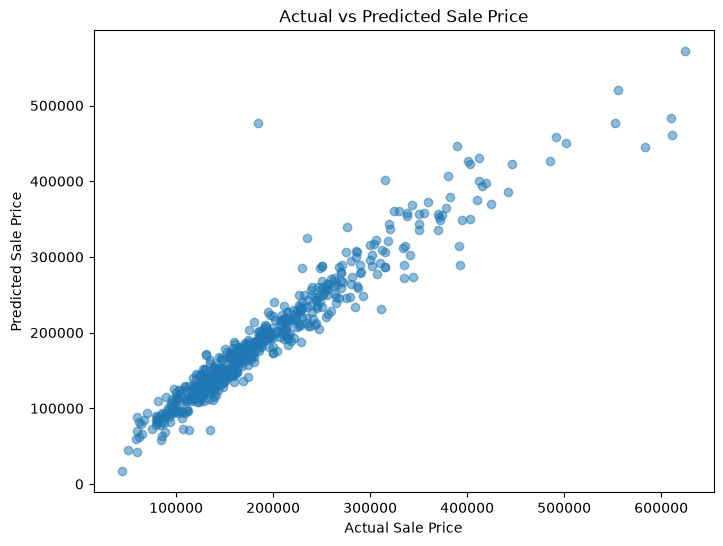

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    gb_tuned_pred,
    alpha=0.5
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")

plt.show()

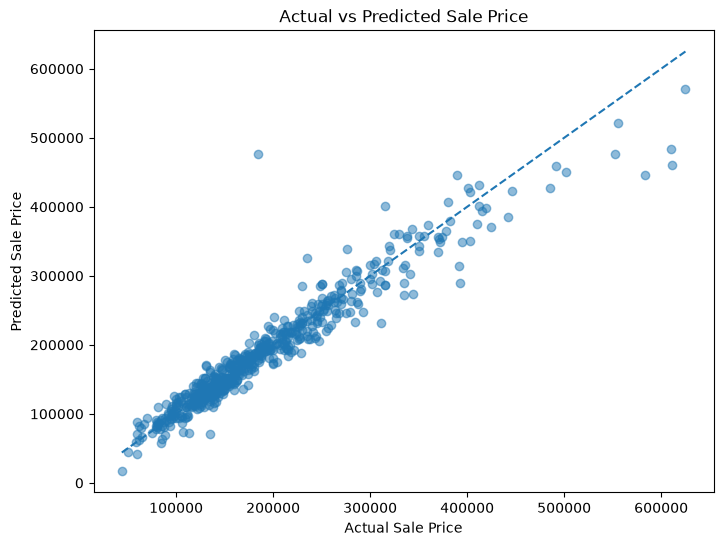

In [177]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    gb_tuned_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")

plt.show()

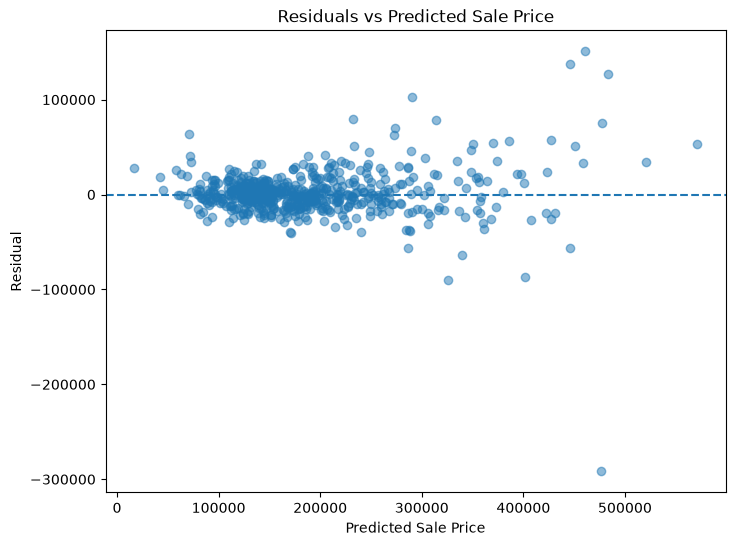

In [178]:
plt.figure(figsize=(8, 6))

plt.scatter(
    gb_tuned_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Sale Price")

plt.show()

In [179]:
print("Mean residual:", residuals.mean())

Mean residual: 1360.499115206731


In [180]:
print(
    "Underpredictions:",
    (residuals > 0).sum()
)

print(
    "Overpredictions:",
    (residuals < 0).sum()
)

Underpredictions: 292
Overpredictions: 294


In [181]:
X_test.loc[
    [2181, 44],
    [
        "Overall Qual",
        "Gr Liv Area",
        "1st Flr SF",
        "Total Bsmt SF",
        "Garage Cars",
        "Garage Area",
        "Year Built",
        "Year Remod/Add",
        "Neighborhood"
    ]
]

,Overall Qual,Gr Liv Area,1st Flr SF,Total Bsmt SF,Garage Cars,Garage Area,Year Built,Year Remod/Add,Neighborhood
2181,10,4676,3138,3138.0,3.0,884.0,2007,2008,Edwards
44,9,2364,2364,2330.0,3.0,820.0,2009,2010,NridgHt


In [182]:
print("Mean residual:", residuals.mean())

print(
    "Underpredictions:",
    (residuals > 0).sum()
)

print(
    "Overpredictions:",
    (residuals < 0).sum()
)

Mean residual: 1360.499115206731
Underpredictions: 292
Overpredictions: 294


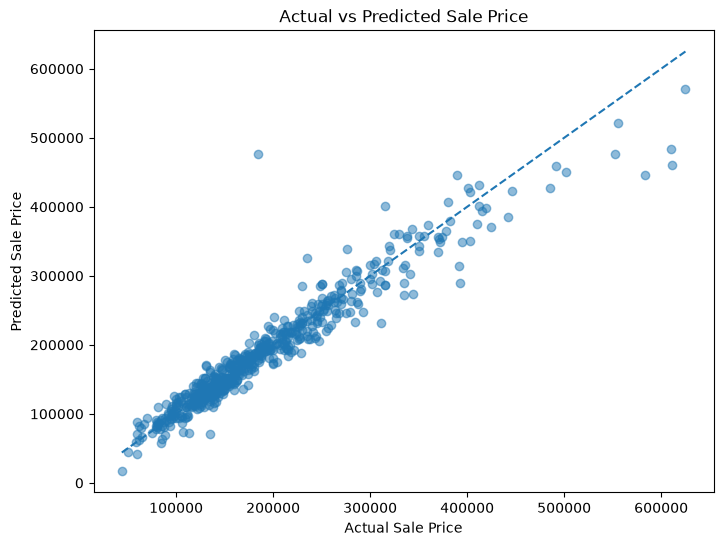

In [183]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    gb_tuned_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")

plt.show()

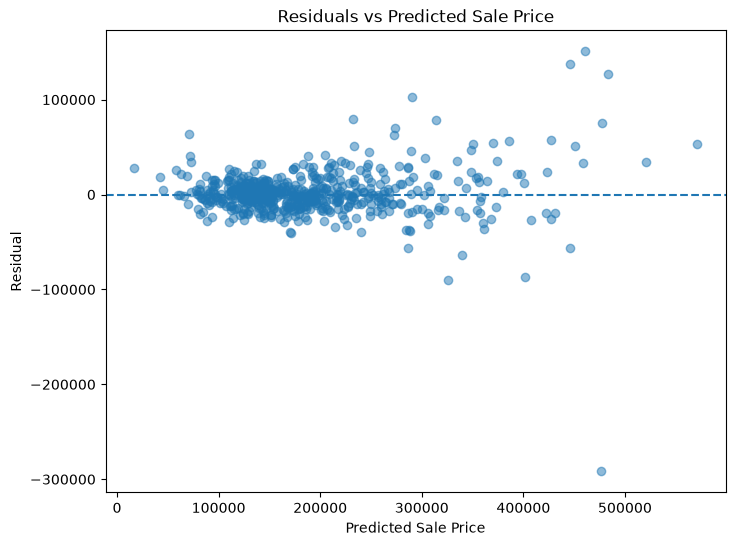

In [184]:
plt.figure(figsize=(8, 6))

plt.scatter(
    gb_tuned_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Sale Price")

plt.show()

In [185]:
from sklearn.inspection import permutation_importance

In [186]:
perm_importance = permutation_importance(
    best_gb,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42
)

In [187]:
perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean
})

In [188]:
perm_importance_df = perm_importance_df.sort_values(
    "importance",
    ascending=False
)

In [189]:
perm_importance_df.head(20)

,feature,importance
18,Overall Qual,20398.553543
47,Gr Liv Area,13487.256034
39,Total Bsmt SF,3377.486042
20,Year Built,2890.387269
35,BsmtFin SF 1,2821.563002
62,Garage Cars,2526.726222
44,1st Flr SF,1343.406732
5,Lot Area,1235.398996
13,Neighborhood,916.990801
1,PID,910.364683
